Random_state:  52
           1E
6   40.258065
22   0.000000
2    2.395161
5    1.145161
0    0.000000

6     1
22    1
2     0
5     0
0     1
Name: Key, dtype: int64
              precision    recall  f1-score   support

     healing       1.00      0.50      0.67         2
 Not-healing       0.75      1.00      0.86         3

   micro avg       0.80      0.80      0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5
 samples avg       0.80      0.80      0.80         5



<Figure size 80000x24000 with 0 Axes>

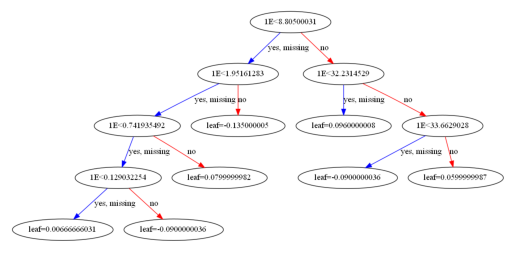

Accuracy: 80.0 %
------------------------------------------XGBClassifier 1-------------------------------
              precision    recall  f1-score   support

     healing       1.00      0.50      0.67         2
 Not-healing       0.75      1.00      0.86         3

   micro avg       0.80      0.80      0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5
 samples avg       0.80      0.80      0.80         5



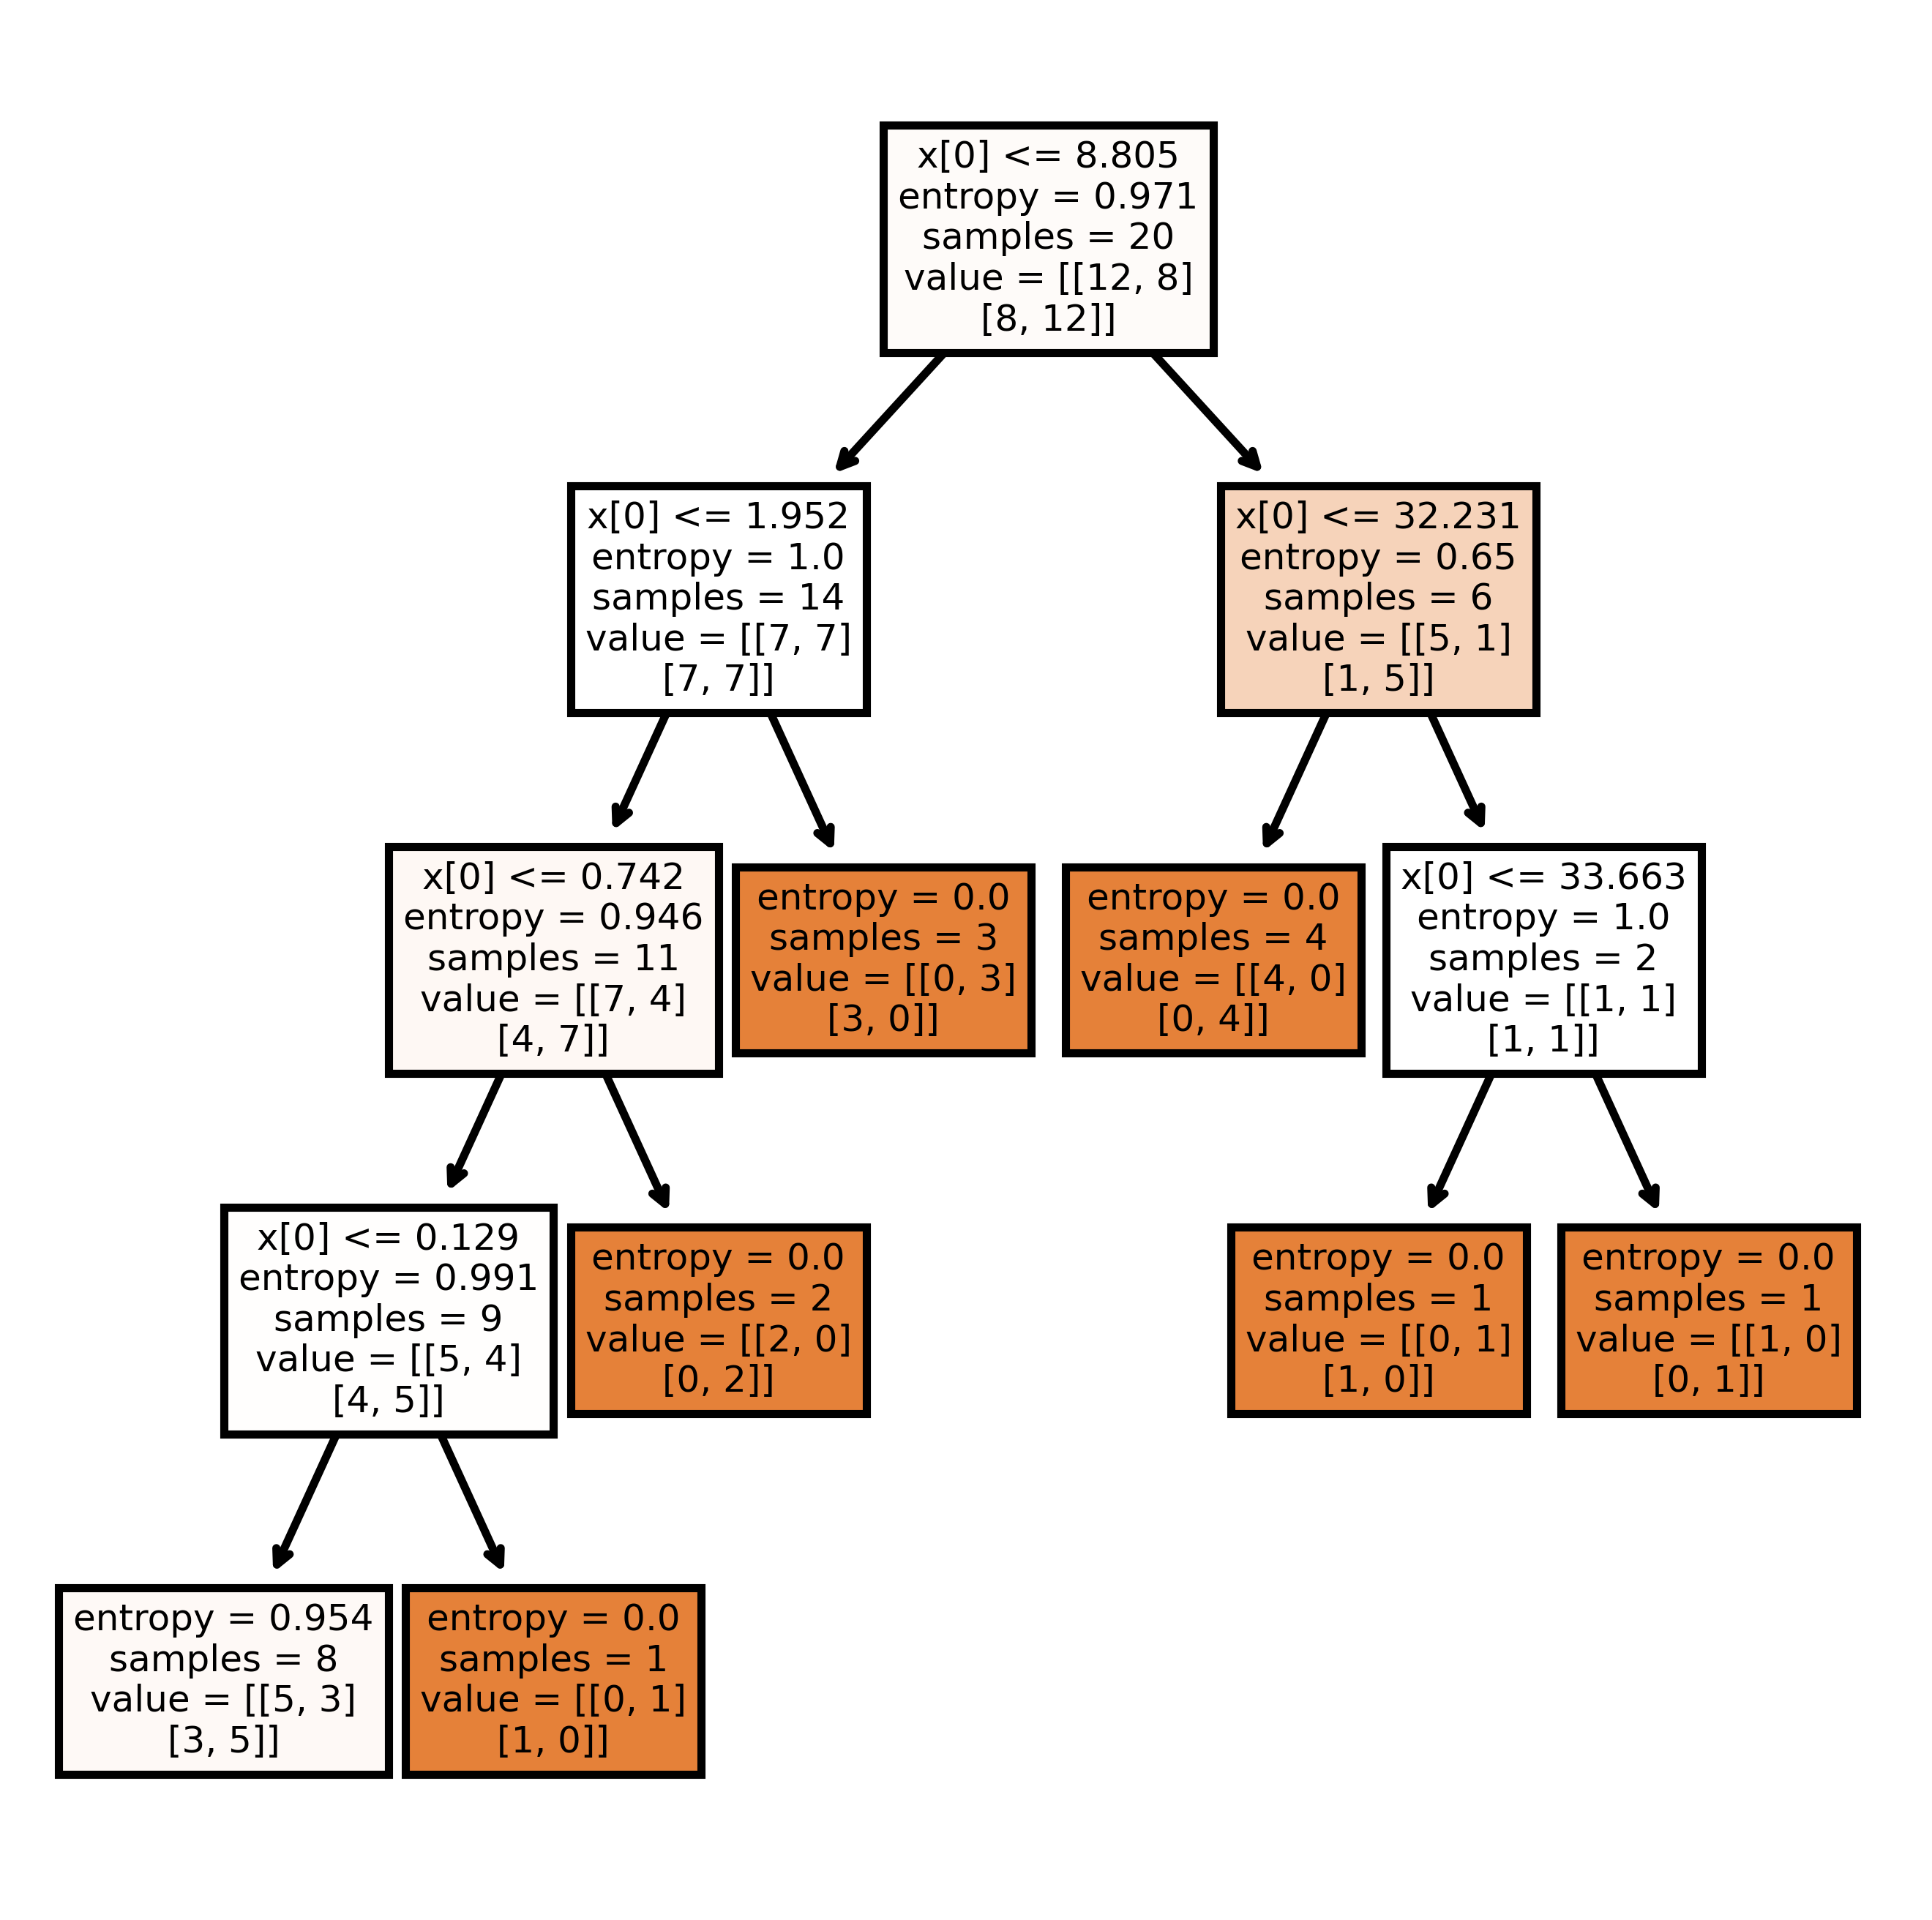

Accuracy: 80.0 %
------------------------------------------DecisionTreeClassifier 2-------------------------------


C:\Users\natej\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:777: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(


              precision    recall  f1-score   support

     healing       0.33      0.50      0.40         2
 Not-healing       0.50      0.33      0.40         3

   micro avg       0.40      0.40      0.40         5
   macro avg       0.42      0.42      0.40         5
weighted avg       0.43      0.40      0.40         5
 samples avg       0.40      0.40      0.40         5



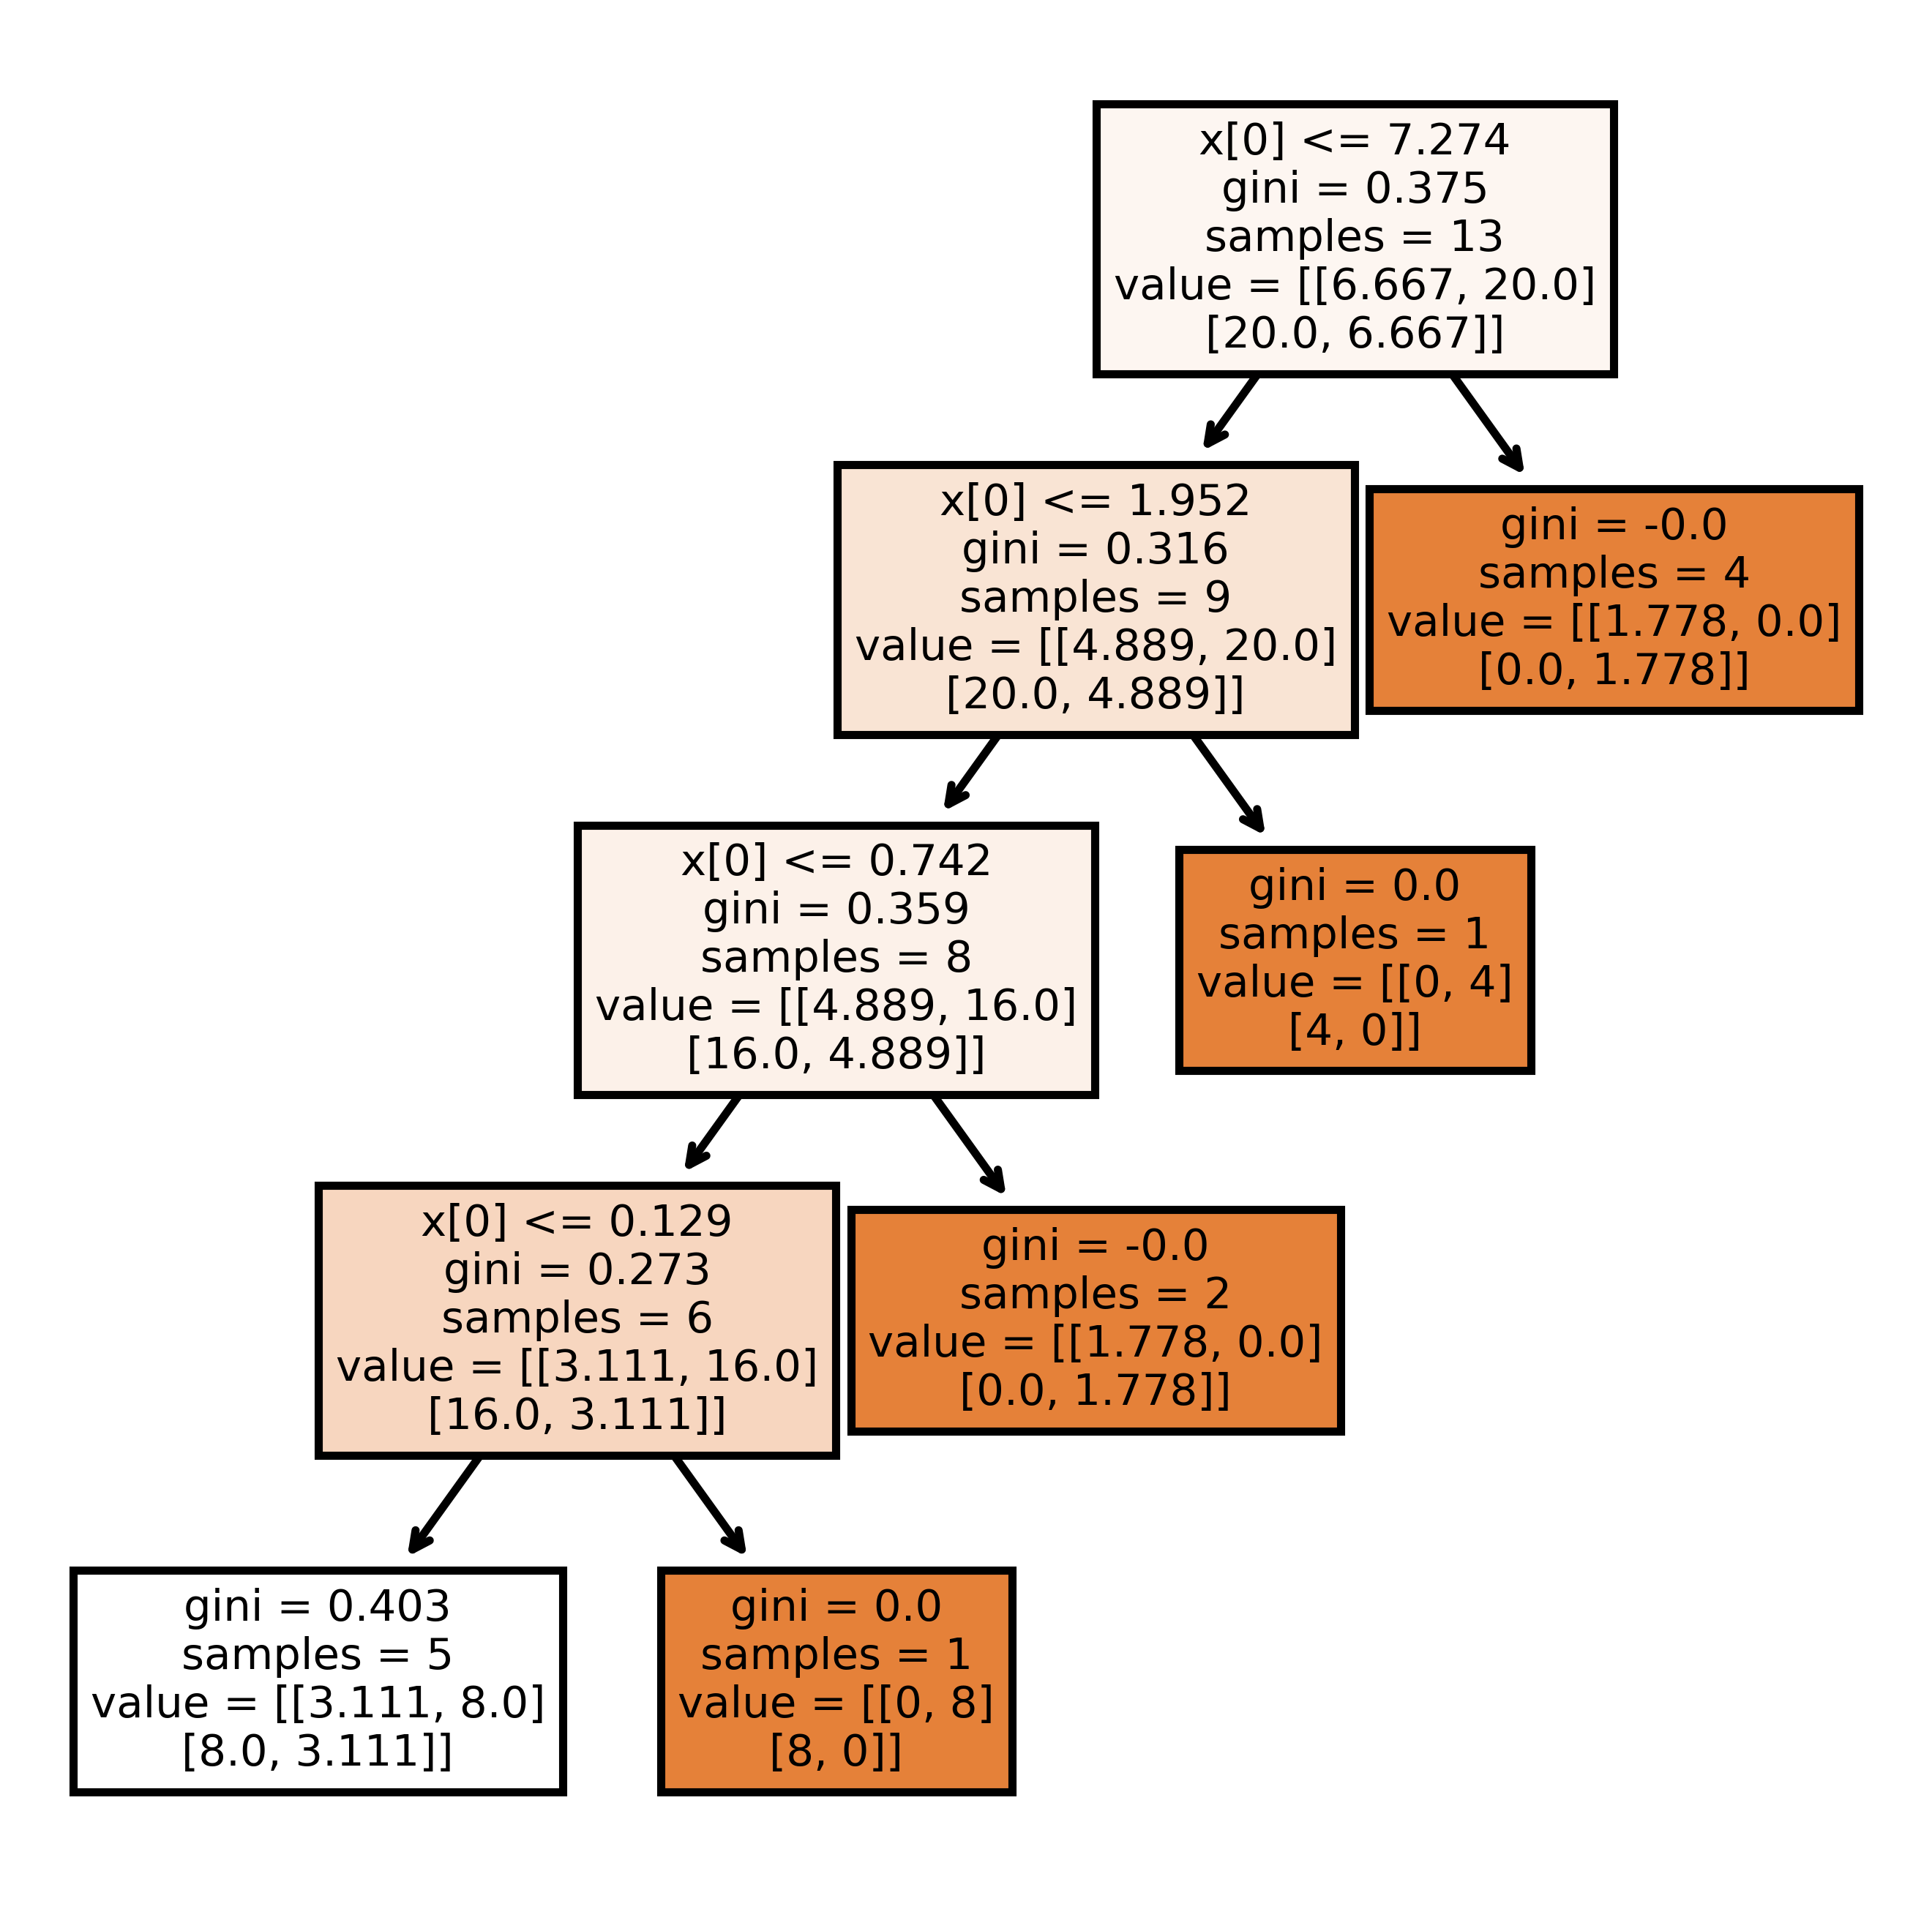

Accuracy: 40.0 %
------------------------------------------RandomForestClassifier 3-------------------------------


C:\Users\natej\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:777: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(


              precision    recall  f1-score   support

     healing       1.00      0.50      0.67         2
 Not-healing       0.75      1.00      0.86         3

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5

Accuracy: 80.0 %
''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
Accuracy: 84.0 %
              precision    recall  f1-score   support

     healing       1.00      0.60      0.75        10
 Not-healing       0.79      1.00      0.88        15

    accuracy                           0.84        25
   macro avg       0.89      0.80      0.82        25
weighted avg       0.87      0.84      0.83        25

[[0.40111951 0.59888049]
 [0.08081166 0.91918834]
 [0.88678421 0.11321578]
 [0.95919255 0.04080745]
 [0.88144516 0.11855485]
 [0.02663736 0.97336264]
 [0.08040432 0.91959568]
 [0.07947833 0.92052167]
 [0.40111951 0.5988

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
import random
from tensorflow.keras.utils import to_categorical
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import pickle



Treatment=pd.read_csv("../dissertation/cell pro 1.csv")

df_x=Treatment.iloc[:,1:]
df_y=Treatment.iloc[:,0]
R_state=random.randrange(1,100)
print("Random_state: ",R_state)
R_state=48
X_train, X_test, y_train, y_test = train_test_split(df_x, df_y,test_size=0.2, random_state=R_state,stratify=df_y)
y_train_clf = to_categorical(y_train)
y_test_clf = to_categorical(y_test)
print(X_test)
print("")
print(y_test)
df_y=to_categorical(df_y)
fullinfo=True
fulltree=True
furtherinfo=False


def class1():
    clf=XGBClassifier(tree_method="exact",
                      objective="reg:squarederror",
    )
    if fullinfo==True:
        clf.fit(X_train, y_train_clf)
        y_pred = clf.predict(X_test)
        y_pred = (y_pred > 0.5) 
        print(classification_report(y_test_clf,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
        
        if fulltree==True:
            clf.fit(X_train, y_train)
            plt.figure(figsize=(800, 240))
            plot_tree(clf)
            #plt.savefig('DTC keras', dpi=1200)
            plt.show()
        accuracy = accuracy_score(y_test_clf, y_pred)
        print("Accuracy:", (accuracy*100),"%")
        print("------------------------------------------XGBClassifier 1-------------------------------")
        if furtherinfo==True:
            print("''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''")
            y_pred = clf.predict(df_x)
           # accuracy = accuracy_score(np.asarray(df_y).argmax(axis=1), y_pred)
            accuracy = accuracy_score(np.asarray(df_y).argmax(axis=1), y_pred)
            print("Accuracy:", (accuracy*100),"%")
            print(classification_report(np.asarray(df_y).argmax(axis=1),y_pred,output_dict=False,target_names=["healing","Not-healing"]))
            f, axes = plt.subplots(1, 2, figsize=(15, 10))
            axes = axes.ravel()
            #goal_class=["Healing","non-healing","deterioration"]
            for i in range(2):
                disp = ConfusionMatrixDisplay(confusion_matrix(np.asarray(df_y).argmax(axis=1),
                                                       y_pred),
                                              display_labels=[0, i])
                disp.plot(ax=axes[i], values_format='.4g')
                #disp.ax_.set_title(goal_class[i])
                if i<10:
                    disp.ax_.set_xlabel('')
                if i%5!=0:
                    disp.ax_.set_ylabel('')
                disp.im_.colorbar.remove()

            plt.subplots_adjust(wspace=0.10, hspace=0.1)
            f.colorbar(disp.im_, ax=axes)
            plt.show()
            print("_______________________________________________________________________________________________")
    return clf

def class2():
    clf=DecisionTreeClassifier(max_depth=None,
                               criterion="entropy",
                               ccp_alpha=0.02,
                              # criterion="log_loss",
                              
    )
    if fullinfo==True:
        clf.fit(X_train, y_train_clf)
        y_pred = clf.predict(X_test)
        y_pred = (y_pred > 0.5) 
        print(classification_report(y_test_clf,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
        if fulltree==True:
            fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)
            tree.plot_tree(clf, 
               filled = True);
            #f, axes = plt.subplots(1, 2, figsize=(15, 10))
            #axes = axes.ravel()
            plt.show()
        accuracy = accuracy_score(y_test_clf, y_pred)
        print("Accuracy:", (accuracy*100),"%")
        print("------------------------------------------DecisionTreeClassifier 2-------------------------------")
        if furtherinfo==True:
            print("''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''")
            y_pred = clf.predict(df_x)
           # accuracy = accuracy_score(np.asarray(df_y).argmax(axis=1), y_pred)
            accuracy = accuracy_score(df_y, y_pred)
            print("Accuracy:", (accuracy*100),"%")
            print(classification_report(df_y,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
            f, axes = plt.subplots(1, 2, figsize=(15, 10))
            axes = axes.ravel()
            #goal_class=["Healing","non-healing","deterioration"]
            for i in range(2):
                disp = ConfusionMatrixDisplay(confusion_matrix(np.asarray(df_y).argmax(axis=1),
                                                       y_pred.argmax(axis=1)),
                                              display_labels=[0, i])
                disp.plot(ax=axes[i], values_format='.4g')
                #disp.ax_.set_title(goal_class[i])
                if i<10:
                    disp.ax_.set_xlabel('')
                if i%5!=0:
                    disp.ax_.set_ylabel('')
                disp.im_.colorbar.remove()

            plt.subplots_adjust(wspace=0.10, hspace=0.1)
            f.colorbar(disp.im_, ax=axes)
            plt.show()
            print("_______________________________________________________________________________________________")
    return clf

def class3():
    clf = RandomForestClassifier(max_depth=6,warm_start=True,class_weight="balanced_subsample",n_estimators=500,random_state=9)
    if fullinfo==True:
        clf.fit(X_train, y_train_clf)
        y_pred = clf.predict(X_test)
        y_pred = (y_pred > 0.5) 
        print(classification_report(y_test_clf,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
        if fulltree==True:
            fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)
            tree.plot_tree(clf.estimators_[0], 
               filled = True);
            #f, axes = plt.subplots(1, 2, figsize=(15, 10))
            #axes = axes.ravel()
            plt.show()
        accuracy = accuracy_score(y_test_clf, y_pred)
        print("Accuracy:", (accuracy*100),"%")
        print("------------------------------------------RandomForestClassifier 3-------------------------------")
        if furtherinfo==True:
            print("''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''")
            y_pred = clf.predict(df_x)
           # accuracy = accuracy_score(np.asarray(df_y).argmax(axis=1), y_pred)
            accuracy = accuracy_score(df_y, y_pred)
            print("Accuracy:", (accuracy*100),"%")
            print(classification_report(df_y,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
            f, axes = plt.subplots(1, 2, figsize=(15, 10))
            axes = axes.ravel()
            #goal_class=["Healing","non-healing","deterioration"]
            for i in range(2):
                disp = ConfusionMatrixDisplay(confusion_matrix(np.asarray(df_y).argmax(axis=1),
                                                       y_pred.argmax(axis=1)),
                                              display_labels=[0, i])
                disp.plot(ax=axes[i], values_format='.4g')
                #disp.ax_.set_title(goal_class[i])
                if i<10:
                    disp.ax_.set_xlabel('')
                if i%5!=0:
                    disp.ax_.set_ylabel('')
                disp.im_.colorbar.remove()

            plt.subplots_adjust(wspace=0.10, hspace=0.1)
            f.colorbar(disp.im_, ax=axes)
            plt.show()
            print("_______________________________________________________________________________________________")
    return clf
    

    
def VoteClass():
    clf1=class1()
    clf2=class2()
    clf3=class3()
    sclf = VotingClassifier(estimators=[('clf1', clf1), ('clf2', clf2), ('clf3', clf3)],voting='soft',flatten_transform=False)
    
    sclf.fit(X_train, y_train)
    
    y_pred = sclf.predict(X_test)
    print(classification_report(np.asarray(y_test_clf).argmax(axis=1),y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
    accuracy = accuracy_score(np.asarray(y_test_clf).argmax(axis=1), y_pred)
    print("Accuracy:", (accuracy*100),"%")
    
    y_pred = sclf.predict_proba(X_test)
    print("''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''")
    y_pred = sclf.predict(df_x)
    accuracy = accuracy_score(np.asarray(df_y).argmax(axis=1), y_pred)
    print("Accuracy:", (accuracy*100),"%")
    print(classification_report(np.asarray(df_y).argmax(axis=1),y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    y_pred = sclf.predict_proba(df_x)
    print(y_pred)
    
    
    

VoteClass()